In [ ]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [ ]:
# Elbow Method
inertia_vals = []
k_range = range(1, 11)

for k in k_range:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  km.fit(X)
  inertia_vals.append(km.inertia_)

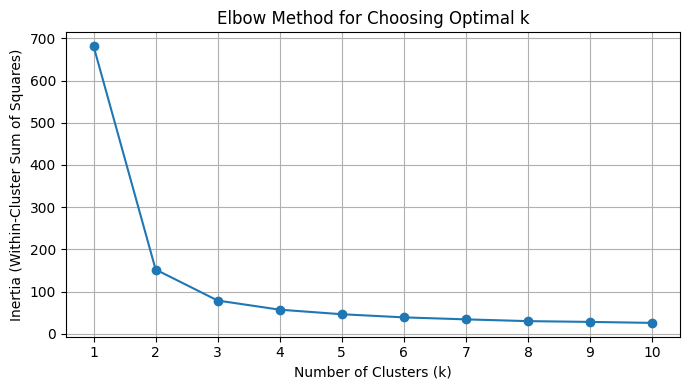

In [ ]:
# Plot the Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia_vals, marker='o')
plt.xticks(k_range)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Choosing Optimal k")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Apply PCA to reduce feature dimensions from 4D to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [ ]:
# Apply KMeans clustering with k = 3
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
cluster_labels = kmeans.fit_predict(X)
centroids_2d = pca.transform(kmeans.cluster_centers_)

In [ ]:
# Create a DataFrame with PCA results and cluster assignments
df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df['Cluster'] = cluster_labels
df['True Label'] = y

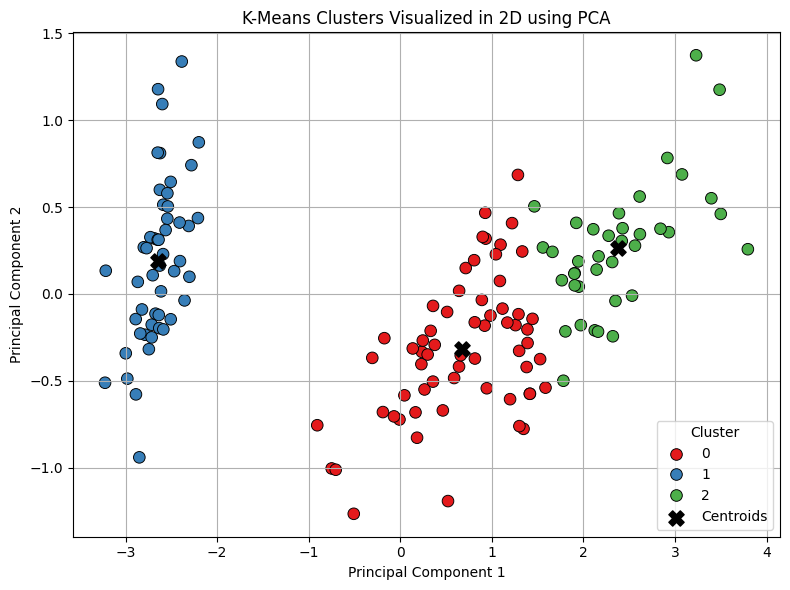

In [ ]:
# Plot the clusters with centroids
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='Cluster',
    palette='Set1', s=70, edgecolor='k'
)
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='black', s=120, marker='X', label='Centroids'
)
plt.title("K-Means Clusters Visualized in 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

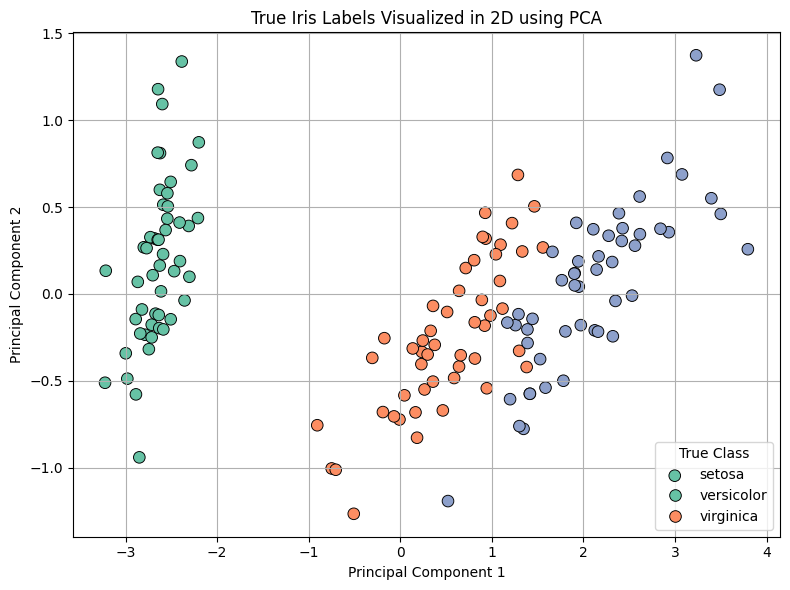

In [ ]:
# Plot the true labels for comparison (optional, for reference)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='PC1', y='PC2', hue='True Label',
    palette='Set2', s=70, edgecolor='k'
)
plt.title("True Iris Labels Visualized in 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="True Class", labels=target_names)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate and print the silhouette score for k=3
sil_score = silhouette_score(X, cluster_labels)
print(f"Silhouette Score for k=3: {sil_score:.3f}")

Silhouette Score for k=3: 0.553
